# Ablation: Component Loss Weight (λ_comp)

Comparing different component loss weights:
- **λ_comp=0.1**: Low component loss weight
- **λ_comp=0.25**: Quarter weight
- **λ_comp=0.5 (Default)**: Default component loss weight
- **λ_comp=0.75**: Higher weight
- **λ_comp=1.0**: Full weight

In [23]:
import sys
import numpy as np
from pathlib import Path

# Import shared ablation utilities
from ablation_utils import (
    setup_plotting_style,
    load_all_ablation_models,
    load_all_models_all_metrics,
    make_latex_ablation_table,
    plot_ablation_line,
    plot_ablation_bars,
    compute_deltas,
    print_summary,
    METRICS, METRIC_DISPLAY, METRIC_COLORS
)

# Set up plotting style
setup_plotting_style()

In [24]:
# =============================================================================
# CONFIGURATION - Define ablation models
# =============================================================================

ABLATION_MODELS = {
    "λ_comp=0.1": {
        "csv_path": "../evaluation/ablations/03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.1_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_0.1.csv",
        "is_baseline": False,
        "description": "Low component loss weight",
        "lambda_value": 0.1
    },
    "λ_comp=0.25": {
        "csv_path": "../evaluation/ablations/03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.25_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_0.25.csv",
        "is_baseline": False,
        "description": "Quarter weight",
        "lambda_value": 0.25
    },
    "λ_comp=0.5 (Default)": {
        "csv_path": "../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv",
        "is_baseline": True,
        "description": "Default component loss weight",
        "lambda_value": 0.5
    },
    "λ_comp=0.75": {
        "csv_path": "../evaluation/ablations/04-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.75_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_0.75.csv",
        "is_baseline": False,
        "description": "Higher weight",
        "lambda_value": 0.75
    },
    "λ_comp=1.0": {
        "csv_path": "../evaluation/ablations/04-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc1.0_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_1.0.csv",
        "is_baseline": False,
        "description": "Full weight",
        "lambda_value": 1.0
    },
}

# Primary metric for comparison
PRIMARY_METRIC = "text_contrastive_accuracy"

# Checkpoint selection (use best or specific step)
CHECKPOINT_STEP = None  # None = use best checkpoint, or specify step like 5000

# Ablation metadata
ABLATION_NAME = "COMPONENT LOSS WEIGHT ABLATION"
PARAM_KEY = "lambda_value"
PARAM_LABEL = r'$\lambda_{comp}$'

print("Ablation: Component Loss Weight (λ_comp)")
print("="*50)
for name, cfg in ABLATION_MODELS.items():
    baseline_mark = " [BASELINE]" if cfg["is_baseline"] else ""
    print(f"  {name}{baseline_mark}: {cfg['description']}")

Ablation: Component Loss Weight (λ_comp)
  λ_comp=0.1: Low component loss weight
  λ_comp=0.25: Quarter weight
  λ_comp=0.5 (Default) [BASELINE]: Default component loss weight
  λ_comp=0.75: Higher weight
  λ_comp=1.0: Full weight


In [25]:
# =============================================================================
# LOAD DATA - Single Metric (Primary)
# =============================================================================

scores_df = load_all_ablation_models(ABLATION_MODELS, PRIMARY_METRIC, CHECKPOINT_STEP)
print(f"\nLoaded {len(scores_df)} models, {len(scores_df.columns)} datasets")

Loading λ_comp=0.1...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded 65 datasets (step=10000)
Loading λ_comp=0.25...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded 65 datasets (step=20000)
Loading λ_comp=0.5 (Default)...
[apply_mappings] Dropped 16 original rows replaced by aliased metrics
  Loaded 65 datasets (step=15000)
Loading λ_comp=0.75...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded 65 datasets (step=15000)
Loading λ_comp=1.0...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded 65 datasets (step=10000)

Common datasets (65): ['ColorFoil', 'VG_Relation', 'VG_Attribution', 'VL_CheckList/attr_color', 'VL_CheckList/attr_size', 'VL_CheckList/obj_location', 'VL_CheckList/attr_action', 'VL_CheckList/rel_action', 'VL_CheckList/rel_spatial', 'VL_CheckList/obj_size', 'VL_CheckList/attr_state', 'VL_CheckList/attr_material', 'MMVP/Text', 'MMVP/Camera Perspective', 'Suga

In [26]:
# =============================================================================
# DISPLAY RAW SCORES TABLE
# =============================================================================

# Convert to percentage and display
scores_pct = scores_df * 100

# Add average column
scores_pct['Average'] = scores_pct.mean(axis=1)

print("\n" + "="*60)
print(f"ABLATION: COMPONENT LOSS WEIGHT (λ_comp)")
print(f"Metric: {PRIMARY_METRIC}")
print("="*60)
display(scores_pct.round(1).style.highlight_max(axis=0, color='lightgreen'))


ABLATION: COMPONENT LOSS WEIGHT (λ_comp)
Metric: text_contrastive_accuracy


,ColorFoil,VG_Relation,VG_Attribution,VL_CheckList/attr_color,VL_CheckList/attr_size,VL_CheckList/obj_location,VL_CheckList/attr_action,VL_CheckList/rel_action,VL_CheckList/rel_spatial,VL_CheckList/obj_size,VL_CheckList/attr_state,VL_CheckList/attr_material,MMVP/Text,MMVP/Camera Perspective,SugarCrepe++/swap_object,VALSE/actions,ControlledImages/COCO-One,SPEC/absolute_size,SugarCrepe/replace_obj,MMVP/State,ColorSwap,VALSE/relations,MMVP/Spatial,SugarCrepe/replace_att,ControlledImages/B,ControlledImages/VG-One,SugarCrepe/swap_att,SugarCrepe++/replace_object,VALSE/noun phrases,ControlledImages/COCO-Two,SugarCrepe/replace_rel,SugarCrepe++/swap_atribute,VALSE/coreference,SPEC/absolute_spatial,MMVP/Structural Character,SPEC/existence,SPEC/relative_size,BLA/co,VALSE/existence,COLA/multi_objects,SugarCrepe++/replace_relation,MMVP/Orientation,NegBench/VOC2007_mcq_llama3.1_rephrased,COCO-CF,BLA/ap,VisMin,MMVP/Color,NegBench/msr_vtt_mcq_rephrased_llama,ControlledImages/VG-Two,SugarCrepe/swap_obj,SugarCrepe++/replace_attribute,NegBench/COCO_val_mcq_llama3.1_rephrased,ControlledImages/A,SugarCrepe/add_obj,Flickr30k_Order,VALSE/counting,SPEC/relative_spatial,MMVP/Quantity,Winoground,SugarCrepe/add_att,BLA/rc,VALSE/plurals,SPEC/count,MMVP/Presence,COCO_Order,Average
Model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
λ_comp=0.1,89.800000,83.400000,69.100000,77.500000,61.400000,93.600000,77.600000,82.700000,79.600000,92.700000,65.500000,72.700000,6.700000,20.000000,54.300000,84.900000,46.400000,39.800000,94.600000,6.700000,57.000000,69.900000,33.300000,86.400000,36.800000,45.600000,73.400000,90.900000,92.800000,52.000000,78.500000,56.500000,56.300000,13.100000,6.700000,65.700000,31.400000,48.200000,83.200000,34.300000,58.800000,13.300000,36.500000,78.100000,51.100000,78.800000,0.000000,28.400000,53.900000,69.800000,71.700000,32.000000,31.100000,88.800000,96.500000,65.800000,29.200000,13.300000,27.800000,80.900000,49.800000,70.300000,35.000000,26.700000,94.800000,56.800000
λ_comp=0.25,89.000000,84.300000,69.000000,79.400000,62.500000,94.100000,78.200000,83.300000,77.900000,93.200000,65.000000,73.700000,0.000000,6.700000,51.800000,83.000000,48.300000,40.900000,94.900000,6.700000,58.300000,68.200000,33.300000,87.900000,36.300000,43.000000,74.900000,90.500000,93.200000,50.900000,79.700000,58.300000,57.400000,12.300000,6.700000,67.400000,32.100000,47.900000,82.400000,33.800000,62.300000,20.000000,35.200000,77.600000,49.900000,77.700000,6.700000,31.000000,50.400000,66.900000,74.000000,26.100000,31.300000,89.500000,96.500000,66.700000,28.700000,13.300000,29.000000,82.400000,49.600000,72.500000,34.000000,13.300000,95.900000,56.600000
λ_comp=0.5 (Default),90.500000,86.300000,69.400000,79.200000,64.300000,94.100000,78.100000,83.000000,80.700000,93.100000,65.200000,74.500000,13.300000,6.700000,52.200000,83.200000,48.000000,38.800000,94.900000,13.300000,59.000000,70.100000,46.700000,86.200000,34.600000,45.100000,74.500000,91.700000,93.700000,50.900000,79.700000,56.500000,56.200000,12.200000,6.700000,68.700000,32.700000,48.400000,83.400000,41.000000,62.400000,13.300000,37.800000,78.200000,52.700000,78.600000,13.300000,29.200000,53.100000,69.000000,74.200000,31.400000,29.100000,90.800000,96.700000,66.500000,29.500000,6.700000,29.800000,80.800000,49.600000,70.500000,34.500000,0.000000,95.300000,57.200000
λ_comp=0.75,89.300000,85.000000,68.300000,79.700000,66.900000,94.300000,78.300000,83.100000,81.100000,93.400000,64.800000,75.800000,0.000000,13.300000,53.900000,84.200000,46.200000,39.300000,94.900000,0.000000,57.700000,69.900000,20.000000,87.200000,34.100000,44.000000,74.500000,91.100000,93.600000,50.700000,80.700000,57.800000,56.400000,12.500000,20.000000,66.200000,33.000000,48.000000,85.100000,35.700000,62.400000,26.700000,39.100000,77.800000,51.200000,78.800000,13.300000,29.800000,50.400000,70.600000,73.200000,30.700000,31.800000,90.900000,96.100000,67.100000,29.200000,13.300000,31.000000,82.900000,49.000000,70.400000,34.900000,13.3

In [27]:
# =============================================================================
# LOAD ALL METRICS (Text, Image, Group Contrastive Accuracy)
# =============================================================================

# Load all models with all metrics
all_metrics_df = load_all_models_all_metrics(ABLATION_MODELS, METRICS, CHECKPOINT_STEP)

# Extract just the summary columns (I2T, T2I, Group)
summary_cols = [col for col in ['I2T', 'T2I', 'Group'] if col in all_metrics_df.columns]
summary_df = all_metrics_df[summary_cols].copy()

# Add overall average
summary_df['Average'] = summary_df.mean(axis=1)

print("\n" + "="*60)
print("ABLATION: COMPONENT LOSS WEIGHT - ALL METRICS")
print("="*60)
display((summary_df * 100).round(1).style.highlight_max(axis=0, color='lightgreen'))

Loading λ_comp=0.1...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ_comp=0.25...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ_comp=0.5 (Default)...
[apply_mappings] Dropped 16 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ_comp=0.75...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ_comp=1.0...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']

Common datasets across all models (19): ['BLA', 'COCO-CF', 'COCO_Order', 'COLA', 'ColorFoil', 'ColorSwap', 'ControlledImages', 'Flickr30k_Order', 'MMVP', 'NegBench', 'SPEC', 'SugarCrepe', 'SugarCrepe++', 'VALSE', 'VG_Attribution', 'VG_Relation', 'VL_CheckList', 'VisMin', 'Winoground']

ABLATION: COMPONENT LOSS WEIGHT - 

,I2T,T2I,Group,Average
Model,,,,
λ_comp=0.1,62.500000,40.200000,23.800000,42.200000
λ_comp=0.25,62.400000,41.100000,24.700000,42.700000
λ_comp=0.5 (Default),63.400000,41.600000,25.400000,43.400000
λ_comp=0.75,62.900000,40.900000,24.600000,42.800000
λ_comp=1.0,62.900000,40.300000,24.700000,42.600000


In [28]:
# =============================================================================
# LATEX TABLE GENERATION
# =============================================================================

# Generate LaTeX table
latex_table = make_latex_ablation_table(
    summary_df,
    ABLATION_MODELS,
    caption="Component loss weight ($\\lambda_{\\text{comp}}$) ablation. I2T = Image-to-Text, T2I = Text-to-Image, Group = both correct. Best in \\textbf{bold}, baseline \\underline{underlined}.",
    label="tab:ablation_comp_lambda",
)

print("="*60)
print("LATEX TABLE")
print("="*60)
print(latex_table)

LATEX TABLE
\begin{table}[t]
  \centering
  \small
  \caption{Component loss weight ($\lambda_{\text{comp}}$) ablation. I2T = Image-to-Text, T2I = Text-to-Image, Group = both correct. Best in \textbf{bold}, baseline \underline{underlined}.}
  \label{tab:ablation_comp_lambda}
  \begin{tabular}{lcccc}
    \toprule
    Model & I2T & T2I & Group & Average \\
    \midrule
    λ\_comp=0.1 & 62.5 & 40.2 & 23.8 & 42.2 \\
    λ\_comp=0.25 & 62.4 & 41.1 & 24.7 & 42.7 \\
    λ\_comp=0.5 (Default) & \textbf{\underline{63.4}} & \textbf{\underline{41.6}} & \textbf{\underline{25.4}} & \textbf{\underline{43.4}} \\
    λ\_comp=0.75 & 62.9 & 40.9 & 24.6 & 42.8 \\
    λ\_comp=1.0 & 62.9 & 40.3 & 24.7 & 42.6 \\
    \bottomrule
  \end{tabular}
\end{table}


In [29]:
# =============================================================================
# VISUALIZATION: LINE PLOT (λ vs Performance)
# =============================================================================

# Extract lambda values and corresponding scores
lambda_values = [ABLATION_MODELS[model]['lambda_value'] for model in summary_df.index]

fig, ax = plot_ablation_line(
    summary_df,
    lambda_values,
    ABLATION_MODELS,
    param_label=PARAM_LABEL,
    title='Component Loss Weight Ablation',
    save_path='../paper_figures/ablation_comp_lambda_line.pdf'
)

TypeError: list indices must be integers or slices, not str

Saved: ../paper_figures/ablation_comp_lambda_bars.pdf


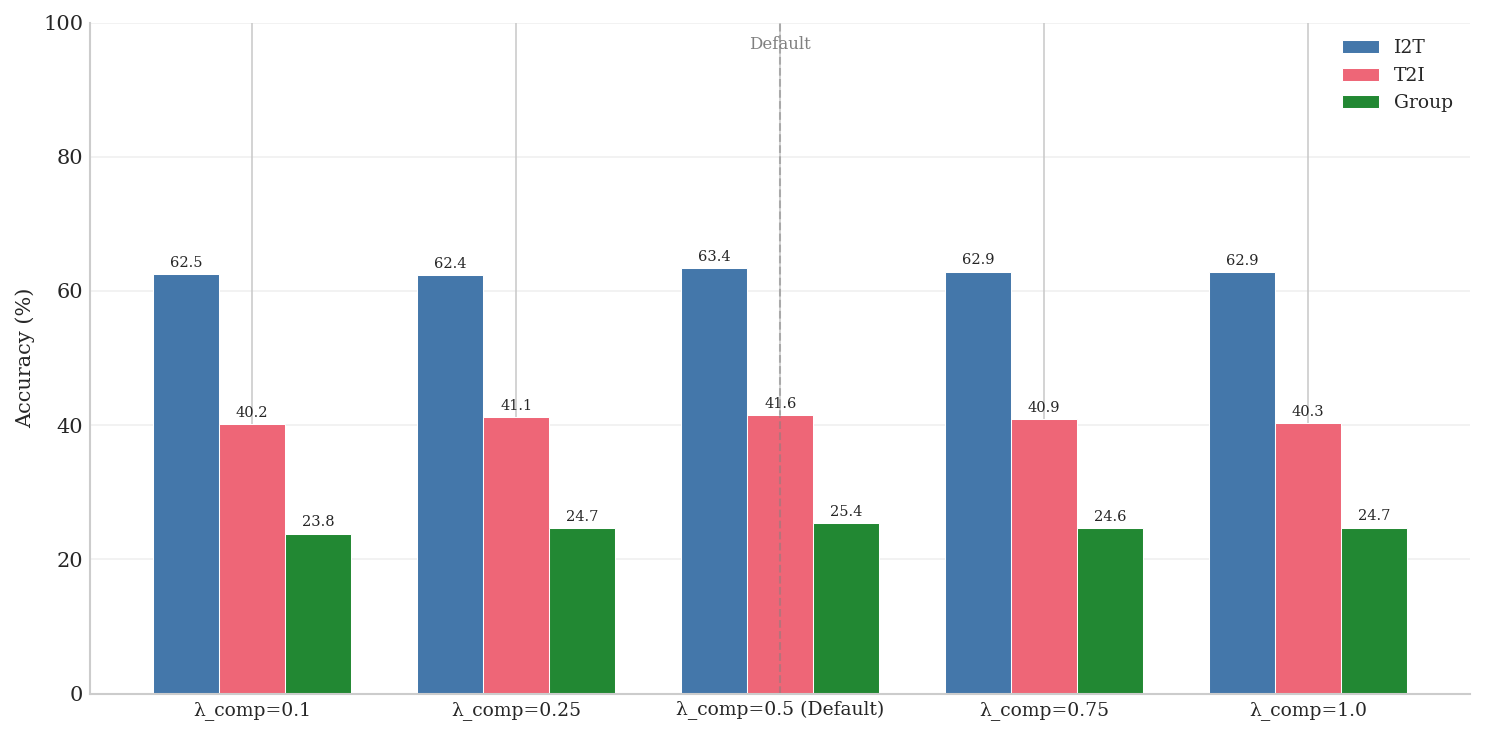

In [30]:
# =============================================================================
# VISUALIZATION: GROUPED BAR CHART (All Metrics)
# =============================================================================

fig, ax = plot_ablation_bars(
    summary_df,
    ABLATION_MODELS,
    title='Component Loss Weight Ablation',
    save_path='../paper_figures/ablation_comp_lambda_bars.pdf'
)

In [31]:
# =============================================================================
# COMPUTE DELTAS FROM BASELINE
# =============================================================================

deltas_df = compute_deltas(summary_df, ABLATION_MODELS)

print("\n" + "="*60)
print("DELTA FROM BASELINE (percentage points)")
print("="*60)
display(deltas_df.round(2).style.background_gradient(cmap='RdYlGn', axis=None))


DELTA FROM BASELINE (percentage points)


,I2T,T2I,Group,Average
Model,,,,
λ_comp=0.1,-0.920000,-1.350000,-1.580000,-1.290000
λ_comp=0.25,-1.000000,-0.410000,-0.730000,-0.710000
λ_comp=0.5 (Default),0.000000,0.000000,0.000000,0.000000
λ_comp=0.75,-0.510000,-0.630000,-0.780000,-0.640000
λ_comp=1.0,-0.530000,-1.200000,-0.680000,-0.800000


In [32]:
# =============================================================================
# SUMMARY
# =============================================================================

print_summary(summary_df, ABLATION_MODELS, ABLATION_NAME, PARAM_KEY)


SUMMARY: COMPONENT LOSS WEIGHT ABLATION

Baseline: λ_comp=0.5 (Default)

Average Performance:
    λ_comp=0.1: 42.2% (-1.29pp vs baseline) | lambda_value=0.1
    λ_comp=0.25: 42.7% (-0.71pp vs baseline) | lambda_value=0.25
  ★ λ_comp=0.5 (Default): 43.4% (+0.00pp vs baseline) | lambda_value=0.5
    λ_comp=0.75: 42.8% (-0.64pp vs baseline) | lambda_value=0.75
    λ_comp=1.0: 42.6% (-0.80pp vs baseline) | lambda_value=1.0

Key Findings:
  - Best: λ_comp=0.5 (Default) (43.4%)
  - Worst: λ_comp=0.1 (42.2%)
  - Gap: 1.3pp


In [35]:
# =============================================================================
# DATASET-WISE AND SUBSET-WISE TABLES (with ARO merging)
# =============================================================================

from ablation_utils import (
    load_all_models_per_dataset,
    load_all_models_per_subset,
    make_latex_dataset_table,
    get_datasets_and_subsets,
    display_all_tables,
    load_benchmark_config
)

# Load benchmark config for dataset merge rules (e.g., ARO)
bench_cfg = load_benchmark_config()

# Display all tables for the primary metric (I2T) with ARO merging
dataset_df, subset_df, datasets_subsets = display_all_tables(
    ABLATION_MODELS, PRIMARY_METRIC, CHECKPOINT_STEP, 
    show_latex=True, apply_merge=True, benchmark_config=bench_cfg
)


PER-DATASET RESULTS (I2T)
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
[apply_mappings] Dropped 16 original rows replaced by aliased metrics
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
[apply_mappings] Dropped 8 original rows replaced by aliased metrics


,ARO,BLA,COCO-CF,COLA,ColorFoil,ColorSwap,ControlledImages,MMVP,NegBench,SPEC,SugarCrepe,SugarCrepe++,VALSE,VL_CheckList,VisMin,Winoground,Average
Model,,,,,,,,,,,,,,,,,
λ_comp=0.1,86.000000,49.700000,78.100000,34.300000,89.800000,57.000000,44.300000,14.100000,32.300000,35.700000,81.800000,66.400000,74.700000,78.200000,78.800000,27.800000,58.100000
λ_comp=0.25,86.500000,49.100000,77.600000,33.800000,89.000000,58.300000,43.400000,11.900000,30.800000,35.900000,82.300000,67.400000,74.800000,78.600000,77.700000,29.000000,57.900000
λ_comp=0.5 (Default),86.900000,50.200000,78.200000,41.000000,90.500000,59.000000,43.500000,13.300000,32.800000,36.100000,82.200000,67.400000,74.800000,79.200000,78.600000,29.800000,59.000000
λ_comp=0.75,86.000000,49.400000,77.800000,35.700000,89.300000,57.700000,42.800000,13.300000,33.200000,35.900000,83.100000,67.700000,75.300000,79.700000,78.800000,31.000000,58.500000
λ_comp=1.0,85.600000,50.200000,78.300000,36.700000,90.000000,57.000000,43.700000,11.900000,34.100000,36.000000,83.300000,66.600000,74.800000,79.000000,78.900000,31.800000,58.600000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{Per-dataset I2T accuracy.}
  \label{tab:ablation_datasets_i2t}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lccccccccccccccccc}
    \toprule
    Model & \rotatebox{60}{ARO} & \rotatebox{60}{BLA} & \rotatebox{60}{COCO-CF} & \rotatebox{60}{COLA} & \rotatebox{60}{ColorFoil} & \rotatebox{60}{ColorSwap} & \rotatebox{60}{ControlledImages} & \rotatebox{60}{MMVP} & \rotatebox{60}{NegBench} & \rotatebox{60}{SPEC} & \rotatebox{60}{SugarCrepe} & \rotatebox{60}{SugarCrepe++} & \rotatebox{60}{VALSE} & \rotatebox{60}{VL\_CheckList} & \rotatebox{60}{VisMin} & \rotatebox{60}{Winoground} & \rotatebox{60}{Avg} \\
    \midrule
    λ\_comp=0.1 & 86.0 & 49.7 & 78.1 & 34.3 & 89.8 & 57.0 & \textbf{44.3} & \textbf{14.1} & 32.3 & 35.7 & 81.8 & 66.4 & 74.7 & 78.2 & 78.8 & 27.8 & 58.1 \\
    λ\_comp=0.25 & 86.5 & 49.1 & 77.6 & 33.8 & 89.0 & 58.3 & 43.4 & 11.9 & 30.8 & 35.9 & 82.3 & 67.4 & 74.8 & 78.6 & 77.7 & 29.0 & 57.9 \\
    λ\_comp

,ColorFoil,ARO/VG_Relation,ARO/VG_Attribution,VL_CheckList/attr_color,VL_CheckList/attr_size,VL_CheckList/obj_location,VL_CheckList/attr_action,VL_CheckList/rel_action,VL_CheckList/rel_spatial,VL_CheckList/obj_size,VL_CheckList/attr_state,VL_CheckList/attr_material,MMVP/Text,MMVP/Camera Perspective,SugarCrepe++/swap_object,VALSE/actions,ControlledImages/COCO-One,SPEC/absolute_size,SugarCrepe/replace_obj,MMVP/State,ColorSwap,VALSE/relations,MMVP/Spatial,SugarCrepe/replace_att,ControlledImages/B,ControlledImages/VG-One,SugarCrepe/swap_att,SugarCrepe++/replace_object,VALSE/noun phrases,ControlledImages/COCO-Two,SugarCrepe/replace_rel,SugarCrepe++/swap_atribute,VALSE/coreference,SPEC/absolute_spatial,MMVP/Structural Character,SPEC/existence,SPEC/relative_size,BLA/co,VALSE/existence,COLA/multi_objects,SugarCrepe++/replace_relation,MMVP/Orientation,NegBench/VOC2007_mcq_llama3.1_rephrased,COCO-CF,BLA/ap,VisMin,MMVP/Color,NegBench/msr_vtt_mcq_rephrased_llama,ControlledImages/VG-Two,SugarCrepe/swap_obj,SugarCrepe++/replace_attribute,NegBench/COCO_val_mcq_llama3.1_rephrased,ControlledImages/A,SugarCrepe/add_obj,ARO/Flickr30k_Order,VALSE/counting,SPEC/relative_spatial,MMVP/Quantity,Winoground,SugarCrepe/add_att,BLA/rc,VALSE/plurals,SPEC/count,MMVP/Presence,ARO/COCO_Order,Average
Model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
λ_comp=0.1,89.800000,83.400000,69.100000,77.500000,61.400000,93.600000,77.600000,82.700000,79.600000,92.700000,65.500000,72.700000,6.700000,20.000000,54.300000,84.900000,46.400000,39.800000,94.600000,6.700000,57.000000,69.900000,33.300000,86.400000,36.800000,45.600000,73.400000,90.900000,92.800000,52.000000,78.500000,56.500000,56.300000,13.100000,6.700000,65.700000,31.400000,48.200000,83.200000,34.300000,58.800000,13.300000,36.500000,78.100000,51.100000,78.800000,0.000000,28.400000,53.900000,69.800000,71.700000,32.000000,31.100000,88.800000,96.500000,65.800000,29.200000,13.300000,27.800000,80.900000,49.800000,70.300000,35.000000,26.700000,94.800000,56.800000
λ_comp=0.25,89.000000,84.300000,69.000000,79.400000,62.500000,94.100000,78.200000,83.300000,77.900000,93.200000,65.000000,73.700000,0.000000,6.700000,51.800000,83.000000,48.300000,40.900000,94.900000,6.700000,58.300000,68.200000,33.300000,87.900000,36.300000,43.000000,74.900000,90.500000,93.200000,50.900000,79.700000,58.300000,57.400000,12.300000,6.700000,67.400000,32.100000,47.900000,82.400000,33.800000,62.300000,20.000000,35.200000,77.600000,49.900000,77.700000,6.700000,31.000000,50.400000,66.900000,74.000000,26.100000,31.300000,89.500000,96.500000,66.700000,28.700000,13.300000,29.000000,82.400000,49.600000,72.500000,34.000000,13.300000,95.900000,56.600000
λ_comp=0.5 (Default),90.500000,86.300000,69.400000,79.200000,64.300000,94.100000,78.100000,83.000000,80.700000,93.100000,65.200000,74.500000,13.300000,6.700000,52.200000,83.200000,48.000000,38.800000,94.900000,13.300000,59.000000,70.100000,46.700000,86.200000,34.600000,45.100000,74.500000,91.700000,93.700000,50.900000,79.700000,56.500000,56.200000,12.200000,6.700000,68.700000,32.700000,48.400000,83.400000,41.000000,62.400000,13.300000,37.800000,78.200000,52.700000,78.600000,13.300000,29.200000,53.100000,69.000000,74.200000,31.400000,29.100000,90.800000,96.700000,66.500000,29.500000,6.700000,29.800000,80.800000,49.600000,70.500000,34.500000,0.000000,95.300000,57.200000
λ_comp=0.75,89.300000,85.000000,68.300000,79.700000,66.900000,94.300000,78.300000,83.100000,81.100000,93.400000,64.800000,75.800000,0.000000,13.300000,53.900000,84.200000,46.200000,39.300000,94.900000,0.000000,57.700000,69.900000,20.000000,87.200000,34.100000,44.000000,74.500000,91.100000,93.600000,50.700000,80.700000,57.800000,56.400000,12.500000,20.000000,66.200000,33.000000,48.000000,85.100000,35.700000,62.400000,26.700000,39.100000,77.800000,51.200000,78.800000,13.300000,29.800000,50.400000,70.600000,73.200000,30.700000,31.800000,90.900000,96.100000,67.100000,29.200000,13.300000,31.000000,82.900000,49.000000,70.40000


LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{Per-subset I2T accuracy.}
  \label{tab:ablation_subsets_i2t}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lcccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccc}
    \toprule
    Model & \rotatebox{60}{ColorFoil} & \rotatebox{60}{ARO/VG\_Relation} & \rotatebox{60}{ARO/VG\_Attribution} & \rotatebox{60}{VL\_CheckList/attr\_color} & \rotatebox{60}{VL\_CheckList/attr\_size} & \rotatebox{60}{VL\_CheckList/obj\_location} & \rotatebox{60}{VL\_CheckList/attr\_action} & \rotatebox{60}{VL\_CheckList/rel\_action} & \rotatebox{60}{VL\_CheckList/rel\_spatial} & \rotatebox{60}{VL\_CheckList/obj\_size} & \rotatebox{60}{VL\_CheckList/attr\_state} & \rotatebox{60}{VL\_CheckList/attr\_material} & \rotatebox{60}{MMVP/Text} & \rotatebox{60}{MMVP/Camera Perspective} & \rotatebox{60}{SugarCrepe++/swap\_object} & \rotatebox{60}{VALSE/actions} & \rotatebox{60}{ControlledImages/COCO-One} & \rotatebox{60}{SPEC/absolute\_s

In [34]:
# =============================================================================
# PER-DATASET LATEX TABLE (for specific datasets with subsets)
# =============================================================================

# Generate separate tables for datasets with multiple subsets
for dataset_name, subsets in sorted(datasets_subsets.items()):
    if len(subsets) > 1:  # Only show datasets with multiple subsets
        print(f"\n{'='*60}")
        print(f"DATASET: {dataset_name} (subsets: {subsets})")
        print("="*60)
        
        # Filter subset_df to only this dataset
        cols = [c for c in subset_df.columns if c.startswith(f"{dataset_name}/") or c == dataset_name]
        if cols:
            ds_df = subset_df[cols]
            ds_pct = ds_df * 100
            ds_pct['Avg'] = ds_pct.mean(axis=1)
            display(ds_pct.round(1).style.highlight_max(axis=0, color='lightgreen'))
            
            # LaTeX
            print("\nLaTeX:")
            print(make_latex_dataset_table(
                ds_df, ABLATION_MODELS,
                caption=f"{dataset_name} subset breakdown (I2T accuracy).",
                label=f"tab:ablation_{dataset_name.lower()}_subsets",
                rotate_headers=False
            ))


DATASET: ARO (subsets: ['COCO_Order', 'Flickr30k_Order', 'VG_Attribution', 'VG_Relation'])


,ARO/VG_Relation,ARO/VG_Attribution,ARO/Flickr30k_Order,ARO/COCO_Order,Avg
Model,,,,,
λ_comp=0.1,83.400000,69.100000,96.500000,94.800000,86.000000
λ_comp=0.25,84.300000,69.000000,96.500000,95.900000,86.500000
λ_comp=0.5 (Default),86.300000,69.400000,96.700000,95.300000,86.900000
λ_comp=0.75,85.000000,68.300000,96.100000,94.400000,86.000000
λ_comp=1.0,84.200000,68.100000,95.600000,94.300000,85.600000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{ARO subset breakdown (I2T accuracy).}
  \label{tab:ablation_aro_subsets}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lccccc}
    \toprule
    Model & ARO/VG\_Relation & ARO/VG\_Attribution & ARO/Flickr30k\_Order & ARO/COCO\_Order & Avg \\
    \midrule
    λ\_comp=0.1 & 83.4 & 69.1 & 96.5 & 94.8 & 86.0 \\
    λ\_comp=0.25 & 84.3 & 69.0 & 96.5 & \textbf{95.9} & 86.5 \\
    λ\_comp=0.5 (Default) & \textbf{\underline{86.3}} & \textbf{\underline{69.4}} & \textbf{\underline{96.7}} & \underline{95.3} & \textbf{\underline{86.9}} \\
    λ\_comp=0.75 & 85.0 & 68.3 & 96.1 & 94.4 & 86.0 \\
    λ\_comp=1.0 & 84.2 & 68.1 & 95.6 & 94.3 & 85.6 \\
    \bottomrule
  \end{tabular}
  \end{adjustbox}
\end{table}

DATASET: BLA (subsets: ['ap', 'co', 'rc'])


,BLA/co,BLA/ap,BLA/rc,Avg
Model,,,,
λ_comp=0.1,48.200000,51.100000,49.800000,49.700000
λ_comp=0.25,47.900000,49.900000,49.600000,49.100000
λ_comp=0.5 (Default),48.400000,52.700000,49.600000,50.200000
λ_comp=0.75,48.000000,51.200000,49.000000,49.400000
λ_comp=1.0,49.700000,50.900000,50.000000,50.200000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{BLA subset breakdown (I2T accuracy).}
  \label{tab:ablation_bla_subsets}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lcccc}
    \toprule
    Model & BLA/co & BLA/ap & BLA/rc & Avg \\
    \midrule
    λ\_comp=0.1 & 48.2 & 51.1 & 49.8 & 49.7 \\
    λ\_comp=0.25 & 47.9 & 49.9 & 49.6 & 49.1 \\
    λ\_comp=0.5 (Default) & \underline{48.4} & \textbf{\underline{52.7}} & \underline{49.6} & \textbf{\underline{50.2}} \\
    λ\_comp=0.75 & 48.0 & 51.2 & 49.0 & 49.4 \\
    λ\_comp=1.0 & \textbf{49.7} & 50.9 & \textbf{50.0} & 50.2 \\
    \bottomrule
  \end{tabular}
  \end{adjustbox}
\end{table}

DATASET: ControlledImages (subsets: ['A', 'B', 'COCO-One', 'COCO-Two', 'VG-One', 'VG-Two'])


...


LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{SugarCrepe++ subset breakdown (I2T accuracy).}
  \label{tab:ablation_sugarcrepe++_subsets}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lcccccc}
    \toprule
    Model & SugarCrepe++/swap\_object & SugarCrepe++/replace\_object & SugarCrepe++/swap\_atribute & SugarCrepe++/replace\_relation & SugarCrepe++/replace\_attribute & Avg \\
    \midrule
    λ\_comp=0.1 & \textbf{54.3} & 90.9 & 56.5 & 58.8 & 71.7 & 66.4 \\
    λ\_comp=0.25 & 51.8 & 90.5 & \textbf{58.3} & 62.3 & 74.0 & 67.4 \\
    λ\_comp=0.5 (Default) & \underline{52.2} & \textbf{\underline{91.7}} & \underline{56.5} & \underline{62.4} & \textbf{\underline{74.2}} & \underline{67.4} \\
    λ\_comp=0.75 & 53.9 & 91.1 & 57.8 & 62.4 & 73.2 & \textbf{67.7} \\
    λ\_comp=1.0 & 49.8 & 91.0 & 55.4 & \textbf{63.4} & 73.5 & 66.6 \\
    \bottomrule
  \end{tabular}
  \end{adjustbox}
\end{table}

DATASET: VALSE (subsets: ['actions', 'coreference', 'counting', 'exist

,VALSE/actions,VALSE/relations,VALSE/noun phrases,VALSE/coreference,VALSE/existence,VALSE/counting,VALSE/plurals,Avg
Model,,,,,,,,
λ_comp=0.1,84.900000,69.900000,92.800000,56.300000,83.200000,65.800000,70.300000,74.700000
λ_comp=0.25,83.000000,68.200000,93.200000,57.400000,82.400000,66.700000,72.500000,74.800000
λ_comp=0.5 (Default),83.200000,70.100000,93.700000,56.200000,83.400000,66.500000,70.500000,74.800000
λ_comp=0.75,84.200000,69.900000,93.600000,56.400000,85.100000,67.100000,70.400000,75.300000
λ_comp=1.0,84.500000,70.700000,93.400000,56.200000,83.000000,65.700000,70.400000,74.800000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{VALSE subset breakdown (I2T accuracy).}
  \label{tab:ablation_valse_subsets}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lcccccccc}
    \toprule
    Model & VALSE/actions & VALSE/relations & VALSE/noun phrases & VALSE/coreference & VALSE/existence & VALSE/counting & VALSE/plurals & Avg \\
    \midrule
    λ\_comp=0.1 & \textbf{84.9} & 69.9 & 92.8 & 56.3 & 83.2 & 65.8 & 70.3 & 74.7 \\
    λ\_comp=0.25 & 83.0 & 68.2 & 93.2 & \textbf{57.4} & 82.4 & 66.7 & \textbf{72.5} & 74.8 \\
    λ\_comp=0.5 (Default) & \underline{83.2} & \underline{70.1} & \textbf{\underline{93.7}} & \underline{56.2} & \underline{83.4} & \underline{66.5} & \underline{70.5} & \underline{74.8} \\
    λ\_comp=0.75 & 84.2 & 69.9 & 93.6 & 56.4 & \textbf{85.1} & \textbf{67.1} & 70.4 & \textbf{75.3} \\
    λ\_comp=1.0 & 84.5 & \textbf{70.7} & 93.4 & 56.2 & 83.0 & 65.7 & 70.4 & 74.8 \\
    \bottomrule
  \end{tabular}
  \end{adjustbox}
\end{table}



,VL_CheckList/attr_color,VL_CheckList/attr_size,VL_CheckList/obj_location,VL_CheckList/attr_action,VL_CheckList/rel_action,VL_CheckList/rel_spatial,VL_CheckList/obj_size,VL_CheckList/attr_state,VL_CheckList/attr_material,Avg
Model,,,,,,,,,,
λ_comp=0.1,77.500000,61.400000,93.600000,77.600000,82.700000,79.600000,92.700000,65.500000,72.700000,78.200000
λ_comp=0.25,79.400000,62.500000,94.100000,78.200000,83.300000,77.900000,93.200000,65.000000,73.700000,78.600000
λ_comp=0.5 (Default),79.200000,64.300000,94.100000,78.100000,83.000000,80.700000,93.100000,65.200000,74.500000,79.200000
λ_comp=0.75,79.700000,66.900000,94.300000,78.300000,83.100000,81.100000,93.400000,64.800000,75.800000,79.700000
λ_comp=1.0,79.300000,62.500000,94.100000,78.800000,82.800000,79.900000,93.200000,65.700000,74.500000,79.000000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{VL_CheckList subset breakdown (I2T accuracy).}
  \label{tab:ablation_vl_checklist_subsets}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lcccccccccc}
    \toprule
    Model & VL\_CheckList/attr\_color & VL\_CheckList/attr\_size & VL\_CheckList/obj\_location & VL\_CheckList/attr\_action & VL\_CheckList/rel\_action & VL\_CheckList/rel\_spatial & VL\_CheckList/obj\_size & VL\_CheckList/attr\_state & VL\_CheckList/attr\_material & Avg \\
    \midrule
    λ\_comp=0.1 & 77.5 & 61.4 & 93.6 & 77.6 & 82.7 & 79.6 & 92.7 & 65.5 & 72.7 & 78.2 \\
    λ\_comp=0.25 & 79.4 & 62.5 & 94.1 & 78.2 & \textbf{83.3} & 77.9 & 93.2 & 65.0 & 73.7 & 78.6 \\
    λ\_comp=0.5 (Default) & \underline{79.2} & \underline{64.3} & \underline{94.1} & \underline{78.1} & \underline{83.0} & \underline{80.7} & \underline{93.1} & \underline{65.2} & \underline{74.5} & \underline{79.2} \\
    λ\_comp=0.75 & \textbf{79.7} & \textbf{66.9} & \textbf{94.3} 